**Fine-tune IndoBERT untuk klasifikasi kategori pengeluaran keuangan**

Pipeline:
1. Load & mapping kategori ke label seragam
2. Gabung semua dataset
3. Preprocessing teks
4. Fine-tune `indobenchmark/indobert-base-p1`
5. Evaluasi model
6. Inference — input teks → prediksi kategori

## Install Dependencies

In [2]:
!pip install transformers datasets scikit-learn torch accelerate -q

## Import Library

In [1]:
import pandas as pd
import numpy as np
import re
import torch
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset
import matplotlib.pyplot as plt
import seaborn as sns

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device    : {DEVICE}")

PyTorch version : 2.10.0+cu128
CUDA available  : True
Using device    : cuda


## Load & Mapping Kategori

Semua kategori dari keempat dataset di-mapping ke **10 kategori seragam**:

| Label Seragam | Deskripsi |
|---|---|
| `Makanan` | Bahan makanan, makan di luar, restoran |
| `Transportasi` | Bensin, parkir, taksi, perawatan kendaraan |
| `Belanja` | Pakaian, elektronik, kebutuhan rumah tangga |
| `Kesehatan` | Dokter, obat, kebugaran, perawatan diri |
| `Hiburan` | Streaming, bioskop, hobi, gaming |
| `Tagihan` | Listrik, air, internet, sewa, langganan |
| `Sosial` | Makan bersama teman, hadiah, aktivitas sosial |
| `Pendidikan` | Kursus, buku, biaya sekolah |
| `Perjalanan` | Tiket pesawat, hotel, wisata |
| `Lainnya` | Uncategorized, donasi, dll |

In [ ]:
# ============================================================
# FIX 1: PERBAIKI CATEGORY MAPPING
# ============================================================

CATEGORY_MAPPING = {
    # --- df_1_translated ---
    'Bahan makanan'          : 'Makanan',
    'Makanan'                : 'Makanan',
    'Angkutan'               : 'Transportasi',
    'Bepergian'              : 'Travel',   # fix: Perjalanan → Transportasi (gabung)
    'Belanja'                : 'Belanja',
    'Medis/Gigi'             : 'Kesehatan',
    'kebugaran'              : 'Kesehatan',
    'Kebersihan Pribadi'     : 'Kesehatan',
    'Hiburan'                : 'Hiburan',
    'Hobi'                   : 'Hiburan',
    'Langganan'              : 'Tagihan',
    'Perumahan dan Utilitas' : 'Tagihan',
    'Aktivitas Teman'        : 'Sosial',
    'Hadiah'                 : 'Sosial',

    # --- expenses_2 ---
    'Food'           : 'Makanan',
    'Transportation' : 'Transportasi',
    'Apparel'        : 'Belanja',
    'Household'      : 'Tagihan',
    'Health'         : 'Kesehatan',
    'Beauty'         : 'Kesehatan',
    'Entertainment'  : 'Hiburan',
    'Education'      : 'Pendidikan',   # ← FIX UTAMA
    'Social Life'    : 'Sosial',
    'Gift'           : 'Sosial',
    'Pet'            : 'Lainnya',
    'Allowance'      : 'Lainnya',
    'Other'          : 'Lainnya',

    # --- df_synthetic ---
    'makanan'     : 'Makanan',
    'transportasi': 'Transportasi',
    'belanja'     : 'Belanja',
    'kesehatan'   : 'Kesehatan',
    'hiburan'     : 'Hiburan',
    'tagihan'     : 'Tagihan',
    'sosial'      : 'Sosial',
    'pendidikan'  : 'Pendidikan',
    'perjalanan'  : 'Travel',
    'lainnya'     : 'Lainnya',

    # --- Data_Finance ---
    'Makan & Minum' : 'Makanan',
    'Tagihan'       : 'Tagihan',
    'Hiburan'       : 'Hiburan',
    'Belanja'       : 'Belanja',
    'Gaji'          : 'Lainnya',
    'Goals'         : 'Lainnya',
    'Uncategorized' : 'Lainnya',
}

print("✅ Mapping diperbaiki!")
print(f"Total kategori: {len(set(CATEGORY_MAPPING.values()))}")
print("Kategori:", sorted(set(CATEGORY_MAPPING.values())))


✅ Mapping diperbaiki!
Total kategori: 10
Kategori: ['Belanja', 'Hiburan', 'Kesehatan', 'Lainnya', 'Makanan', 'Pendidikan', 'Sosial', 'Tagihan', 'Transportasi', 'Travel']


In [ ]:
# ============================================================
# LOAD & TRANSFORM SETIAP DATASET
# ============================================================

# --- Dataset 1: df_1_translated ---
df1 = pd.read_csv('df_1_translated.csv')
df1 = df1[['Item', 'Category']].rename(columns={'Item': 'text', 'Category': 'label_raw'})

# --- Dataset 2: expenses_2 ---
df2 = pd.read_csv('expenses_2.csv')
df2 = df2[['Note', 'Category']].rename(columns={'Note': 'text', 'Category': 'label_raw'})

# --- Dataset 3: df_synthetic ---
df3 = pd.read_csv('dataset_pengeluaran_synthetic.csv')
df3 = df3[['text', 'category']].rename(columns={'text': 'text', 'category': 'label_raw'})

# --- Dataset 4: Data_Finance ---
df4 = pd.read_csv('Data_Finance.csv')
# Hanya pakai data EXPENSE (bukan INCOME)
df4 = df4[df4['Type'] == 'EXPENSE'][['Title', 'Category']].rename(columns={'Title': 'text', 'Category': 'label_raw'})

# --- Dataset 5: df2_translated ---
df5 = pd.read_csv('df2_translated.csv')
df5 = df5[['Customer ID', 'Category']].rename(columns={'Customer ID': 'text', 'Category': 'label_raw'})

# Gabung semua
df_all = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

# Apply mapping
df_all['label'] = df_all['label_raw'].map(CATEGORY_MAPPING)

# Cek kategori yang belum ter-mapping
unmapped = df_all[df_all['label'].isna()]['label_raw'].unique()
if len(unmapped) > 0:
    print(f"Kategori belum ter-mapping ({len(unmapped)}): {unmapped}")
    print("   → Akan diisi sebagai 'Lainnya'")
    df_all['label'] = df_all['label'].fillna('Lainnya')

# Drop missing text
df_all = df_all.dropna(subset=['text', 'label'])
df_all['text'] = df_all['text'].astype(str).str.strip()
df_all = df_all[df_all['text'] != '']

print(f"\nTotal data gabungan: {len(df_all):,} baris")
print("\nDistribusi label:")
print(df_all['label'].value_counts().to_string())


Total data gabungan: 43,596 baris

Distribusi label:
label
Lainnya         6364
Kesehatan       6251
Sosial          5895
Makanan         5457
Tagihan         4715
Transportasi    3902
Belanja         3821
Pendidikan      3578
Hiburan         2860
Travel           753


In [29]:
df_all = pd.read_csv('dataset_clean_dup5.csv')

In [10]:
df_all.head()

,deskripsi,category,source
0,susu,makanan,df1
1,makan malam bersama teman,sosial,df1
2,tagihan air,tagihan,df1
3,kelas yoga,kesehatan dan perawatan diri,df1
4,bunga,sosial,df1


## Preprocessing Teks

In [30]:
# ============================================================
# PREPROCESS TEXT
# ============================================================

def preprocess_text(text):
    """Bersihkan teks: lowercase, hapus karakter aneh, normalisasi spasi."""

    text = str(text).lower().strip()

    text = re.sub(
        r'[^a-zA-Z0-9\s\'\-àáâãäåèéêëìíîïòóôõöùúûü]',
        ' ',
        text
    )

    text = re.sub(r'\s+', ' ', text).strip()

    return text


# ============================================================
# CLEAN TEXT
# ============================================================

df_all['text_clean'] = df_all['deskripsi'].apply(preprocess_text)

In [12]:
df_all.head()

,deskripsi,category,source,text_clean
0,susu,makanan,df1,susu
1,makan malam bersama teman,sosial,df1,makan malam bersama teman
2,tagihan air,tagihan,df1,tagihan air
3,kelas yoga,kesehatan dan perawatan diri,df1,kelas yoga
4,bunga,sosial,df1,bunga


## Label Encoding & Train/Val/Test Split

In [31]:
# Label encoding
le = LabelEncoder()
df_all['label_id'] = le.fit_transform(df_all['category'])

LABELS = list(le.classes_)
NUM_LABELS = len(LABELS)
print(f"Jumlah kelas: {NUM_LABELS}")
print(f"Label: {LABELS}")

# Split: 70% train, 15% val, 15% test
X = df_all['text_clean'].values
y = df_all['label_id'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"\nData Split:")
print(f"  Train : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Val   : {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test  : {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

Jumlah kelas: 10
Label: ['belanja', 'hiburan', 'kesehatan dan perawatan diri', 'lainnya', 'makanan', 'pendidikan', 'sosial', 'tagihan', 'transportasi', 'travel']

Data Split:
  Train : 9,918 (70.0%)
  Val   : 2,125 (15.0%)
  Test  : 2,126 (15.0%)


## Tokenisasi dengan IndoBERT

In [32]:
# Model: IndoBERT (multilingual, cocok untuk teks Indonesia + Inggris)
MODEL_NAME = 'indobenchmark/indobert-base-p1'
# Alternatif jika mau yang murni multilingual:
# MODEL_NAME = 'bert-base-multilingual-cased'

print(f"Memuat tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 64  # Teks pengeluaran biasanya pendek

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN
    )

# Buat HuggingFace Dataset
train_dataset = Dataset.from_dict({'text': X_train.tolist(), 'labels': y_train.tolist()})
val_dataset   = Dataset.from_dict({'text': X_val.tolist(),   'labels': y_val.tolist()})
test_dataset  = Dataset.from_dict({'text': X_test.tolist(),  'labels': y_test.tolist()})

# Tokenisasi
train_tokenized = train_dataset.map(tokenize_function, batched=True)
val_tokenized   = val_dataset.map(tokenize_function,   batched=True)
test_tokenized  = test_dataset.map(tokenize_function,  batched=True)

print("Tokenisasi selesai!")
print(f"Contoh token: {train_tokenized[0]['input_ids'][:10]} ...")

Memuat tokenizer: indobenchmark/indobert-base-p1


Map:   0%|          | 0/9918 [00:00<?, ? examples/s]

Map:   0%|          | 0/2125 [00:00<?, ? examples/s]

Map:   0%|          | 0/2126 [00:00<?, ? examples/s]

Tokenisasi selesai!
Contoh token: [2, 14886, 7437, 4017, 3, 0, 0, 0, 0, 0] ...


## Load Model & Fine-Tuning

In [33]:
# Load pre-trained model dengan classification head
print(f"Memuat model: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={i: l for i, l in enumerate(LABELS)},
    label2id={l: i for i, l in enumerate(LABELS)}
)

print(f"Model dimuat! Parameters: {model.num_parameters():,}")

Memuat model: indobenchmark/indobert-base-p1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model dimuat! Parameters: 124,449,034


In [35]:
from sklearn.utils.class_weight import compute_class_weight
from torch import nn

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print("=== CLASS WEIGHTS ===")
for i, (label, weight) in enumerate(zip(LABELS, class_weights)):
    print(f"  {label:<30} {weight:.4f}")

# Custom Trainer yang override loss function
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights.to(self.args.device)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # CrossEntropy dengan class weight
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

=== CLASS WEIGHTS ===
  belanja                        0.7396
  hiburan                        1.4982
  kesehatan dan perawatan diri   0.6482
  lainnya                        8.5500
  makanan                        0.7676
  pendidikan                     0.6590
  sosial                         0.6092
  tagihan                        1.8538
  transportasi                   0.9978
  travel                         3.1486


In [36]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc}

# Training Arguments (sama seperti milikmu)
training_args = TrainingArguments(
    output_dir                  = './results_weighted',
    num_train_epochs            = 5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    warmup_ratio                = 0.1,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'accuracy',
    greater_is_better           = True,
    logging_dir                 = './logs',
    logging_steps               = 50,
    fp16                        = torch.cuda.is_available(),
    report_to                   = 'none',
    seed                        = 42,
)

# Pakai WeightedTrainer (ganti Trainer biasa)
trainer = WeightedTrainer(
    class_weights   = class_weights_tensor,
    model           = model,
    args            = training_args,
    train_dataset   = train_tokenized,
    eval_dataset    = val_tokenized,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [37]:
print("\nMulai training dengan class weight...")
train_result = trainer.train()

print("\n✅ Training selesai!")
print(f"Training loss akhir : {train_result.training_loss:.4f}")


Mulai training dengan class weight...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.423554,0.345292,0.912471
2,0.203960,0.250738,0.935529
3,0.067791,0.270338,0.950118
4,0.052267,0.288078,0.954353
5,0.009264,0.270760,0.956706


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✅ Training selesai!
Training loss akhir : 0.2681


In [38]:
# Evaluasi detail per kelas
predictions_output = trainer.predict(test_tokenized)
y_pred = np.argmax(predictions_output.predictions, axis=-1)

print("\n=== CLASSIFICATION REPORT (TEST SET) ===")
print(classification_report(y_test, y_pred, target_names=LABELS))


=== CLASSIFICATION REPORT (TEST SET) ===
                              precision    recall  f1-score   support

                     belanja       0.95      0.95      0.95       288
                     hiburan       0.95      0.94      0.95       142
kesehatan dan perawatan diri       0.96      0.96      0.96       328
                     lainnya       0.76      0.64      0.70        25
                     makanan       0.97      0.96      0.97       277
                  pendidikan       0.98      0.97      0.98       323
                      sosial       0.97      0.97      0.97       349
                     tagihan       0.85      0.91      0.88       114
                transportasi       0.97      0.98      0.97       213
                      travel       0.87      0.88      0.87        67

                    accuracy                           0.95      2126
                   macro avg       0.92      0.92      0.92      2126
                weighted avg       0.95      0

In [17]:
import numpy as np
from sklearn.metrics import accuracy_score
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
import torch

# Metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc}

# Training Arguments
training_args = TrainingArguments(
    output_dir                  = './results',
    num_train_epochs            = 5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    warmup_ratio                = 0.1,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    eval_strategy               = 'epoch', # Changed from evaluation_strategy
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'accuracy',
    greater_is_better           = True,
    logging_dir                 = './logs',
    logging_steps               = 50,
    fp16                        = torch.cuda.is_available(),  # Mixed precision jika ada GPU
    report_to                   = 'none',
    seed                        = 42,
)

# Trainer
trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_tokenized,
    eval_dataset    = val_tokenized,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Mulai fine-tuning...")
print(f"Total training steps: {len(train_tokenized) // training_args.per_device_train_batch_size * training_args.num_train_epochs}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Mulai fine-tuning...
Total training steps: 1545


In [18]:
# 🚀 TRAINING
train_result = trainer.train()

print("\n✅ Training selesai!")
print(f"Training loss akhir : {train_result.training_loss:.4f}")
print(f"Training time       : {train_result.metrics['train_runtime']:.1f} detik")

Epoch,Training Loss,Validation Loss,Accuracy
1,0.299989,0.309048,0.915765
2,0.183149,0.198441,0.946824
3,0.087717,0.181369,0.955765
4,0.050348,0.195326,0.952000
5,0.013756,0.187183,0.955765


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✅ Training selesai!
Training loss akhir : 0.2344
Training time       : 362.4 detik


## Evaluasi Model

In [19]:
# Evaluasi pada test set
print("Evaluasi pada Test Set...")
predictions_output = trainer.predict(test_tokenized)
y_pred = np.argmax(predictions_output.predictions, axis=-1)

acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=LABELS, digits=4))

Evaluasi pada Test Set...



🎯 Test Accuracy: 0.9516 (95.16%)

📋 Classification Report:
                              precision    recall  f1-score   support

                     belanja     0.9298    0.9653    0.9472       288
                     hiburan     0.9627    0.9085    0.9348       142
kesehatan dan perawatan diri     0.9544    0.9573    0.9559       328
                     lainnya     0.7407    0.8000    0.7692        25
                     makanan     0.9887    0.9458    0.9668       277
                  pendidikan     0.9720    0.9690    0.9705       323
                      sosial     0.9628    0.9628    0.9628       349
                     tagihan     0.8803    0.9035    0.8918       114
                transportasi     0.9765    0.9765    0.9765       213
                      travel     0.8451    0.8955    0.8696        67

                    accuracy                         0.9516      2126
                   macro avg     0.9213    0.9284    0.9245      2126
                weighted avg

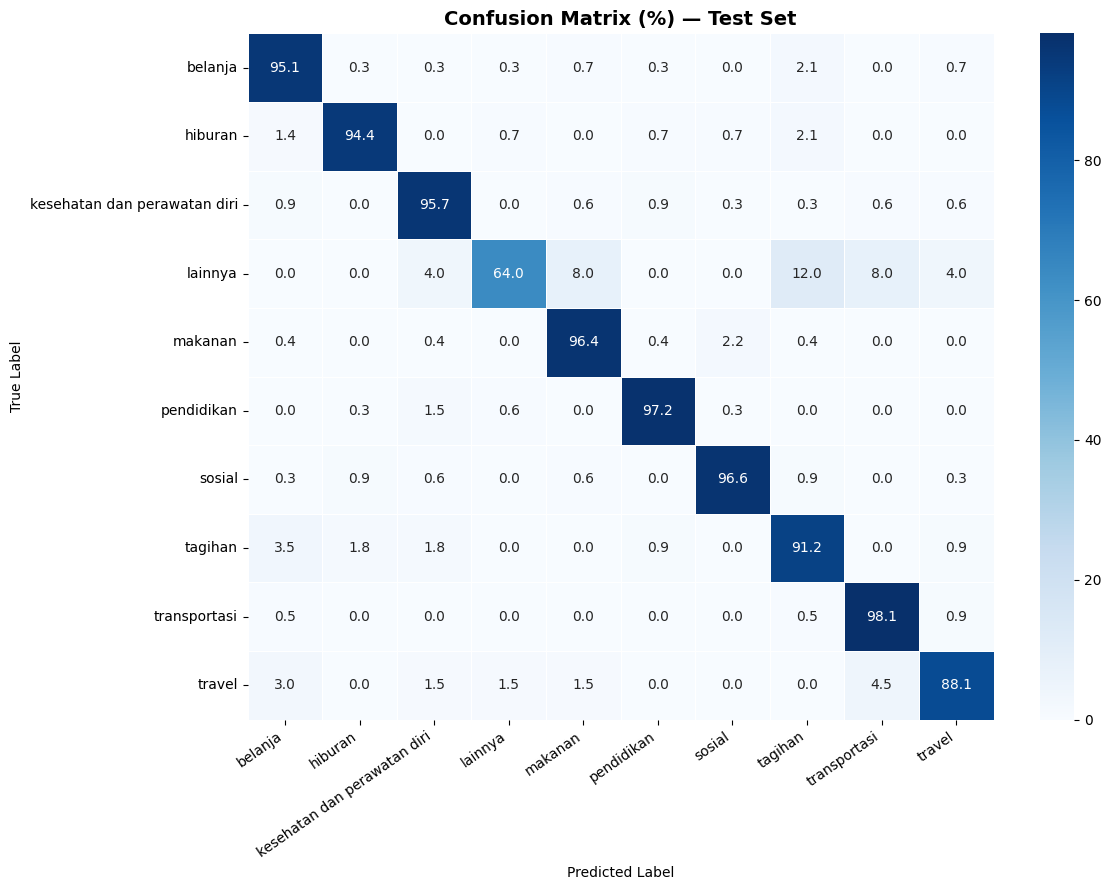

Confusion matrix disimpan: confusion_matrix.png


In [39]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    cm_pct, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=LABELS, yticklabels=LABELS, ax=ax,
    linewidths=0.5
)
ax.set_title('Confusion Matrix (%) — Test Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix disimpan: confusion_matrix.png")

## Simpan Model

In [40]:
import json

SAVE_DIR = './expense_classifier_model'

# Simpan model & tokenizer
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Simpan label mapping
label_info = {
    'labels': LABELS,
    'id2label': {str(i): l for i, l in enumerate(LABELS)},
    'label2id': {l: i for i, l in enumerate(LABELS)},
    'num_labels': NUM_LABELS,
    'model_name': MODEL_NAME,
    'max_len': MAX_LEN
}
with open(f'{SAVE_DIR}/label_info.json', 'w') as f:
    json.dump(label_info, f, indent=2, ensure_ascii=False)

print(f"✅ Model disimpan di: {SAVE_DIR}/")
print(f"   - config.json")
print(f"   - pytorch_model.bin")
print(f"   - tokenizer files")
print(f"   - label_info.json")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model disimpan di: ./expense_classifier_model/
   - config.json
   - pytorch_model.bin
   - tokenizer files
   - label_info.json


## Prediksi Kategori

In [41]:
import json
from transformers import pipeline

# Load model dari disk (bisa dijalankan ulang tanpa training)
SAVE_DIR = './expense_classifier_model'

classifier = pipeline(
    'text-classification',
    model=SAVE_DIR,
    tokenizer=SAVE_DIR,
    device=0 if torch.cuda.is_available() else -1,
    top_k=3  # Tampilkan top 3 prediksi
)

def predict_category(text, top_k=3, show_all=False):
    """
    Prediksi kategori pengeluaran dari teks.

    Args:
        text     : str  — kalimat/kata pengeluaran
        top_k    : int  — jumlah prediksi teratas
        show_all : bool — tampilkan semua skor

    Returns:
        dict dengan 'label', 'score', dan 'top_predictions'
    """
    text_clean = preprocess_text(text)
    results = classifier(text_clean, top_k=top_k)  # Removed the extra [0] here

    best = results[0]
    output = {
        'input'           : text,
        'label'           : best['label'],
        'confidence'      : f"{best['score']*100:.1f}%",
        'top_predictions' : [{r['label']: f"{r['score']*100:.1f}%"} for r in results]
    }
    return output

# ============================================================
# 🧪 TEST INFERENCE
# ============================================================
test_inputs = [
    # Bahasa Indonesia
    "warung nasi padang",
    "bayar token listrik",
    "bensin motor",
    "beli baju di Shopee",
    "nonton film di bioskop",
    "obat batuk di apotek",
    "tiket kereta ke Surabaya",
    "kursus bahasa Inggris",
    "kado ulang tahun teman",
    # Bahasa Inggris
    "grocery shopping",
    "Netflix subscription",
    "taxi fare to airport",
    # Campuran
    "GoPay ke Gofood McD",
    "top up OVO bayar parkir",
]

print(f"{'='*65}")
print(f"{'INPUT':<35} {'PREDIKSI':<18} {'CONFIDENCE'}")
print(f"{'='*65}")
for text in test_inputs:
    result = predict_category(text)
    print(f"{result['input']:<35} {result['label']:<18} {result['confidence']}")
print(f"{'='*65}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

INPUT                               PREDIKSI           CONFIDENCE
warung nasi padang                  makanan            99.6%
bayar token listrik                 tagihan            99.8%
bensin motor                        transportasi       99.2%
beli baju di Shopee                 belanja            96.4%
nonton film di bioskop              hiburan            99.6%
obat batuk di apotek                kesehatan dan perawatan diri 99.5%
tiket kereta ke Surabaya            transportasi       99.7%
kursus bahasa Inggris               pendidikan         99.8%
kado ulang tahun teman              sosial             99.8%
grocery shopping                    kesehatan dan perawatan diri 52.6%
Netflix subscription                hiburan            99.8%
taxi fare to airport                transportasi       99.7%
GoPay ke Gofood McD                 makanan            99.4%
top up OVO bayar parkir             transportasi       99.7%


In [46]:
# ============================================================
# INTERACTIVE
# ============================================================
while True:
    user_input = input("\n📝 Masukkan deskripsi pengeluaran (ketik 'exit' untuk keluar): ").strip()
    if user_input.lower() in ['exit', 'quit', 'q', '']:
        print("Selesai!")
        break

    result = predict_category(user_input, top_k=3)
    print(f"\n  ✅ Kategori   : {result['label']}")
    print(f"  📊 Confidence  : {result['confidence']}")
    print(f"  🔢 Top 3       :")
    for pred in result['top_predictions']:
        for lbl, score in pred.items():
            print(f"     - {lbl:<20} {score}")


  ✅ Kategori   : travel
  📊 Confidence  : 97.7%
  🔢 Top 3       :
     - travel               97.7%
     - hiburan              1.3%
     - sosial               0.5%

  ✅ Kategori   : tagihan
  📊 Confidence  : 99.8%
  🔢 Top 3       :
     - tagihan              99.8%
     - travel               0.0%
     - pendidikan           0.0%

  ✅ Kategori   : transportasi
  📊 Confidence  : 99.8%
  🔢 Top 3       :
     - transportasi         99.8%
     - makanan              0.1%
     - kesehatan dan perawatan diri 0.0%

  ✅ Kategori   : transportasi
  📊 Confidence  : 99.8%
  🔢 Top 3       :
     - transportasi         99.8%
     - kesehatan dan perawatan diri 0.1%
     - tagihan              0.1%

  ✅ Kategori   : makanan
  📊 Confidence  : 99.6%
  🔢 Top 3       :
     - makanan              99.6%
     - sosial               0.2%
     - lainnya              0.0%

  ✅ Kategori   : tagihan
  📊 Confidence  : 99.4%
  🔢 Top 3       :
     - tagihan              99.4%
     - lainnya              0.2%


🎯 Test Accuracy: 0.9539 (95.39%)

📋 Classification Report:
                              precision    recall  f1-score   support

                     belanja     0.9514    0.9514    0.9514       288
                     hiburan     0.9504    0.9437    0.9470       142
kesehatan dan perawatan diri     0.9602    0.9573    0.9588       328
                     lainnya     0.7619    0.6400    0.6957        25
                     makanan     0.9674    0.9639    0.9656       277
                  pendidikan     0.9782    0.9721    0.9752       323
                      sosial     0.9740    0.9656    0.9698       349
                     tagihan     0.8525    0.9123    0.8814       114
                transportasi     0.9676    0.9812    0.9744       213
                      travel     0.8676    0.8806    0.8741        67

                    accuracy                         0.9539      2126
                   macro avg     0.9231    0.9168    0.9193      2126
                weighted avg 

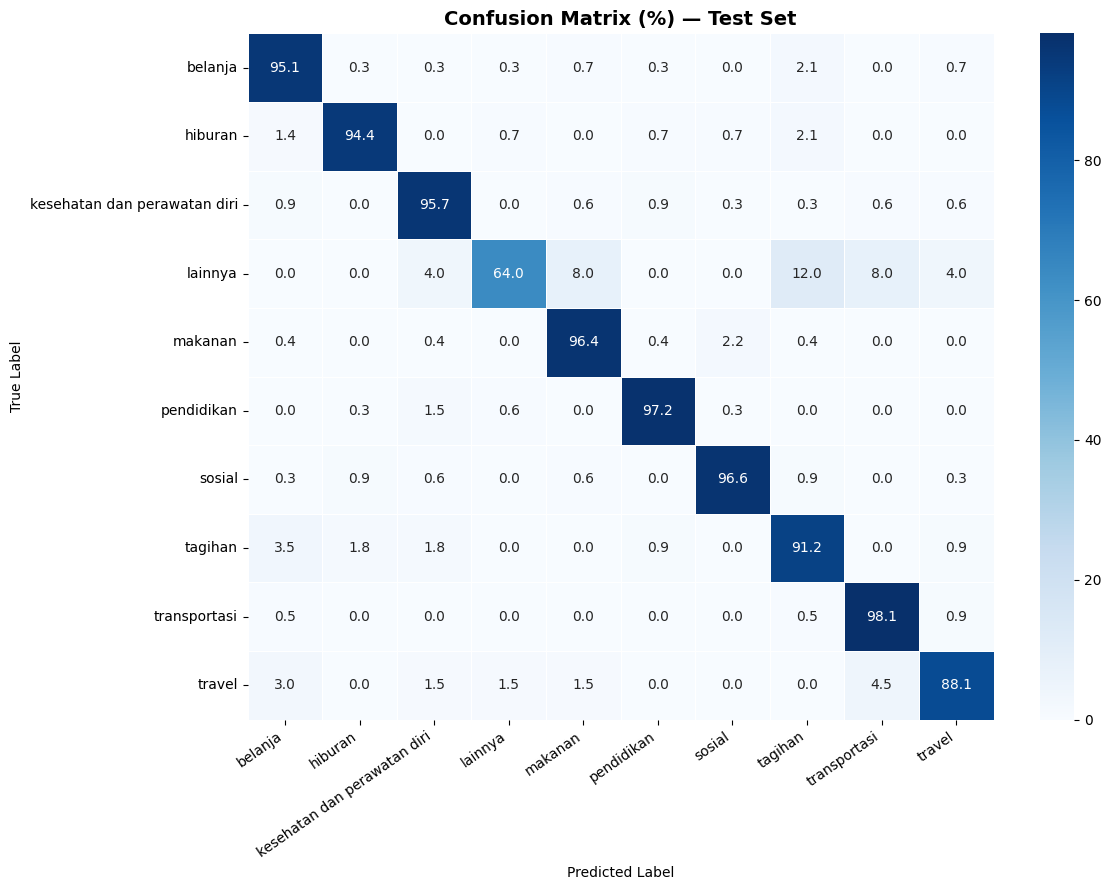


=== JUMLAH DATA PER LABEL (training) ===
category
sosial                          2326
kesehatan dan perawatan diri    2186
pendidikan                      2150
belanja                         1916
makanan                         1846
transportasi                    1420
hiburan                          946
tagihan                          764
travel                           449
lainnya                          166

Label paling sedikit: lainnya (166 data)
Label paling banyak: sosial (2326 data)


In [47]:
# ============================================================
# EVALUASI LENGKAP — Classification Report per Kategori
# ============================================================

predictions_output = trainer.predict(test_tokenized)
y_pred = np.argmax(predictions_output.predictions, axis=-1)

acc = accuracy_score(y_test, y_pred)
print(f"🎯 Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=LABELS, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    cm_pct, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=LABELS, yticklabels=LABELS, ax=ax,
    linewidths=0.5
)
ax.set_title('Confusion Matrix (%) — Test Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Distribusi data training per label (biar tau mana yang datanya sedikit)
print("\n=== JUMLAH DATA PER LABEL (training) ===")
label_counts = df_all['category'].value_counts()
print(label_counts.to_string())
print(f"\nLabel paling sedikit: {label_counts.idxmin()} ({label_counts.min()} data)")
print(f"Label paling banyak: {label_counts.idxmax()} ({label_counts.max()} data)")